# I. Lựa chọn dữ liệu 

In [37]:
import numpy as np 

cau = [
    "Mùa hè 2026 đánh dấu sự trở lại đầy bùng nổ của chuỗi hoạt động học thuật thường niên tại MLIoT Lab",
    "Chương trình năm nay mang đến hai khóa học cốt lõi hoàn toàn phi lợi nhuận dành cho các bạn sinh viên đam mê công nghệ",
    "Khóa học truyền thống Python & Machine Learning sẽ tiếp tục là bệ phóng vững chắc cho hành trình chinh phục AI của bạn",
    "Khóa học Embedded C hứa hẹn mở ra thế giới lập trình nhúng và thiết kế phần cứng đầy thú vị trên nền STM32",
    "Lab còn tổ chức chuỗi Workshop và Seminar chuyên sâu về AI cũng như Software Engineering",
    "Học viên sẽ được trang bị các kỹ năng bổ trợ thực tế như quy trình làm việc nhóm qua Git, GitHub và các công cụ phát triển dự án",
    "Đây là cơ hội tuyệt vời để bạn tích lũy kiến thức mới và làm project thực tế và kết nối với những người bạn cùng chí hướng",
    "Đừng bỏ lỡ cơ hội bứt phá trong mùa hè này và hãy nhanh tay đăng ký để trở thành một phần của MLIoT Lab nhé"
]

# output của vocab là một list chứa các từ vựng duy nhất (set()) được sắp xếp theo thứ tự tăng dần (sorted())
vocab = sorted({w for s in cau for w in s.lower().split()})

# Vectorize các câu (str -> vector)
def to_vector(s):
    v = np.zeros(len(vocab))
    for w in s.lower().split():
        v[vocab.index(w)] += 1
    return v



# Bài 1 - Biểu diễn dữ liệu thành ma trận và độ tương đồng

### 1. Biến dữ liệu thành ma trận

In [38]:

X = np.array([to_vector(s) for s in cau])
print(f"Kích thước của ma trận X: {X.shape}") # Kích thước: (8,153)

# Ma trận X có 8 hàng đại diện cho 8 câu mẫu
# Có 153 cột. Mỗi cột có các phần tử là các từ vựng duy nhất đã được sắp xếp trong biến vocab
# Giá trị tại vị trí X[i, j] thể hiện tần suất xuất hiện của từ thứ j trong câu thứ i


Kích thước của ma trận X: (8, 153)


### 2. Phép toán cơ bản

In [39]:
# Tính vector trung bình theo từng cột 
X_mean = X.mean(axis=0)

# Thực hiện trừ trung bình (dịch chuyển vector về gốc tọa độ)
X_centered = X - X_mean

# Quy tắc broadcasting đã sao chép vector X_mean (153,) thành một arr có 8 hàng giống nhau để thực hiện phép trừ
print(f"Kích thước của ma trận X ban đầu: {X.shape}")
print(f"Kích thước của vector X_mean: {X_mean.shape}")
print(f"Kích thước của ma trận sau khi trừ trung bình: {X_centered.shape}")

Kích thước của ma trận X ban đầu: (8, 153)
Kích thước của vector X_mean: (153,)
Kích thước của ma trận sau khi trừ trung bình: (8, 153)


### 3. Cosine similarity

In [40]:
def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X
    
    # Chuẩn hóa theo từng hàng, giữ nguyên chiều
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
    Yn = Y / np.linalg.norm(Y, axis=1, keepdims=True)
    
    return Xn @ Yn.T

print(f"Kích thước ma trận tương đồng: {cosine_similarity(X).shape}")

Kích thước ma trận tương đồng: (8, 8)


### 4. Truy vấn

In [44]:
def search(query, top_k=3):
    '''
    Input đầu vào là một câu dùng để query và Output là hàm sẽ trả 3 câu (top_k = 3) giống nhất kèm theo điểm cosine
    '''
    # Trả về top K = 3
    q = to_vector(query).reshape(1,-1) #Chuyển về cùng kích thước để phù hợp với đầu vào của hàm cosine_similarity
    scores = cosine_similarity(q, X)[0]
    top_res = np.argsort(scores)[::-1][:top_k] # Sắp xếp lại giảm dần và lấy 3 phần tử đầu (top_k = 3)
   
    print(f"Kết quả tìm kiếm cho query: '{query}' với top_k = 3")
    print("-" * 50)
    
    for i in top_res:
        print(f"{cau[i]}")
        print(f"-> Độ tương đồng cosine: {scores[i]:.4f}\n")
        
    # Tính cặp giống nhau và khác nhau nhất
    most_similar = np.argmax(scores)
    least_similar = np.argmin(scores)
    print("-" * 60)

    print("Câu giống nhất:")
    print(cau[most_similar])
    print(f"-> Độ tương đồng cosine: {scores[most_similar]:.4f}\n")

    print("Câu khác nhất:")
    print(cau[least_similar])
    print(f"-> Độ tương đồng cosine: {scores[least_similar]:.4f}")

search("Hãy đăng ký khóa học Machine Learning và AI")


Kết quả tìm kiếm cho query: 'Hãy đăng ký khóa học Machine Learning và AI' với top_k = 3
--------------------------------------------------
Khóa học truyền thống Python & Machine Learning sẽ tiếp tục là bệ phóng vững chắc cho hành trình chinh phục AI của bạn
-> Độ tương đồng cosine: 0.3402

Đừng bỏ lỡ cơ hội bứt phá trong mùa hè này và hãy nhanh tay đăng ký để trở thành một phần của MLIoT Lab nhé
-> Độ tương đồng cosine: 0.2615

Khóa học Embedded C hứa hẹn mở ra thế giới lập trình nhúng và thiết kế phần cứng đầy thú vị trên nền STM32
-> Độ tương đồng cosine: 0.2041

------------------------------------------------------------
Câu giống nhất:
Khóa học truyền thống Python & Machine Learning sẽ tiếp tục là bệ phóng vững chắc cho hành trình chinh phục AI của bạn
-> Độ tương đồng cosine: 0.3402

Câu khác nhất:
Mùa hè 2026 đánh dấu sự trở lại đầy bùng nổ của chuỗi hoạt động học thuật thường niên tại MLIoT Lab
-> Độ tương đồng cosine: 0.0711


### 5. Nhận xét

##### Nhìn chung, kết quả trả về ở cả 2 cặp giống nhất và khác nhất tương tự với trực giác
- **Về câu giống nhất:**
Câu **"Khóa học truyền thống Python & Machine Learning...hành trình chinh phục AI của bạn"** chứa các từ khóa như **"khóa học", "Machine learning", "AI"**

**Kết luận:** Các từ khóa này cũng đồng thời xuất hiện trong câu query nên có điểm cosine cao nhất (tương đồng nhất)

- **Về câu khác nhất:**
Câu **"Mùa hè 2026 đánh dấu...hoạt động học thuật thường niên tại MLIoT Lab"** gần như không chứa từ khóa tương đồng nào so với query ngoại trừ từ **"học"**

**Kết luận:** vì số từ khóa xuất hiện quá ít nên giá trị cosine cũng tiến gần về 0 (khác nhau nhất)

# BÀI 2 - BIẾN ĐỔI TUYẾN TÍNH & SVD

### 1. Giảm chiều bằng SVD

In [60]:
# center dữ liệu về gốc tọa độ
X_c = X - X.mean(axis=0)

# Thực hiện SVD decomposition
U, S, Vt = np.linalg.svd(X_c, full_matrices=False)

# Tọa độ 2D của các câu
coords = U[:, :2] * S[:2]

print(f"Kích thước ma trận tọa độ 2D mới: {coords.shape}")

Kích thước ma trận tọa độ 2D mới: (8, 2)


### 2. Trực quan hóa bằng matplotlib

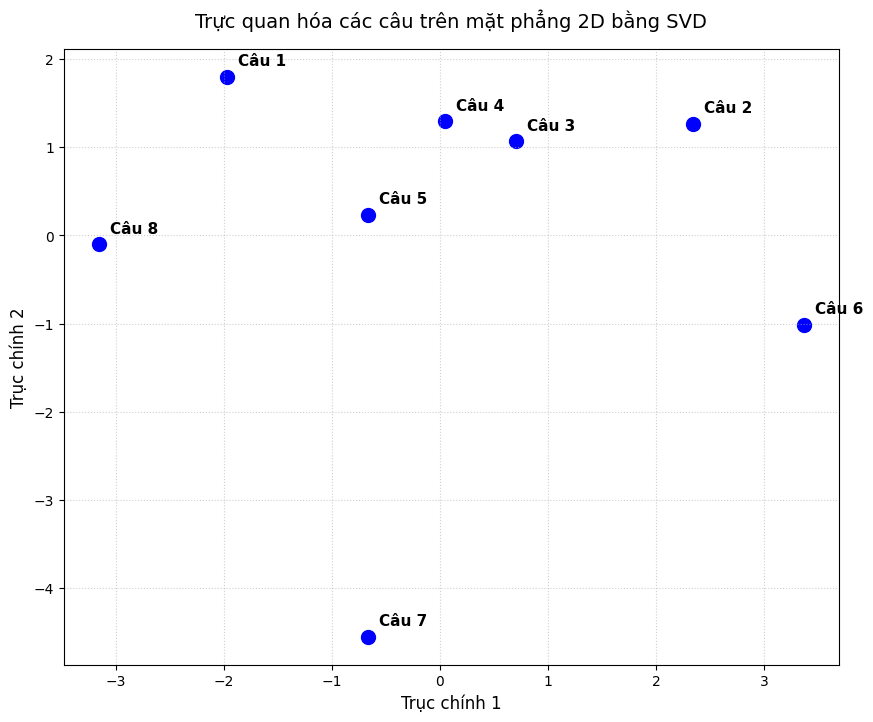

C1: Mùa hè 2026 đánh dấu sự trở lại đầy bùng nổ của chuỗi hoạt động học thuật thường niên tại MLIoT Lab
C2: Chương trình năm nay mang đến hai khóa học cốt lõi hoàn toàn phi lợi nhuận dành cho các bạn sinh viên đam mê công nghệ
C3: Khóa học truyền thống Python & Machine Learning sẽ tiếp tục là bệ phóng vững chắc cho hành trình chinh phục AI của bạn
C4: Khóa học Embedded C hứa hẹn mở ra thế giới lập trình nhúng và thiết kế phần cứng đầy thú vị trên nền STM32
C5: Lab còn tổ chức chuỗi Workshop và Seminar chuyên sâu về AI cũng như Software Engineering
C6: Học viên sẽ được trang bị các kỹ năng bổ trợ thực tế như quy trình làm việc nhóm qua Git, GitHub và các công cụ phát triển dự án
C7: Đây là cơ hội tuyệt vời để bạn tích lũy kiến thức mới và làm project thực tế và kết nối với những người bạn cùng chí hướng
C8: Đừng bỏ lỡ cơ hội bứt phá trong mùa hè này và hãy nhanh tay đăng ký để trở thành một phần của MLIoT Lab nhé


In [61]:
import matplotlib.pyplot as plt

# Xây dựng kích thước đồ thị
plt.figure(figsize=(10, 8))

# Vẽ các điểm tọa độ 2D của 8 câu
plt.scatter(coords[:, 0], coords[:, 1], color="blue", s=100)

# Gắn nhãn cho từng điểm tương ứng với số thứ tự của câu
for i, (x_coord, y_coord) in enumerate(coords):
    plt.annotate(
        f"Câu {i+1}", 
        (x_coord, y_coord), 
        textcoords="offset points", # Căn chỉnh vị trí của nhãn
        xytext=(8,8), 
        ha="left",
        fontsize=11,
        weight="bold"
    )

# Đặt tên cho tiêu đề và các trục
plt.title("Trực quan hóa các câu trên mặt phẳng 2D bằng SVD", fontsize=14, pad=15)
plt.xlabel("Trục chính 1", fontsize=12)
plt.ylabel("Trục chính 2", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

# Hiển thị đồ thị
plt.show()

for i, sen in enumerate(cau):
    print(f"C{i+1}: {sen}")

### 3. Liên hệ với Eigen/PCA và "trục chính của dữ liệu"

Việc áp dụng SVD để giảm chiều có mối liên hệ chặt chẽ với PCA vì Các singular values thu được từ SVD liên quan đến lại liên quan đến trị riêng (eigenvalues) của ma trận hiệp phương sai qua đó phản ánh mức độ biến thiên của dữ liệu theo từng hướng.

- **Trục chính thứ nhất (PC1):** là hướng mà dữ liệu có phương sai lớn nhất (nắm giữ nhiều thông tin nhất) của tập dữ liệu. Trong bài 2, trục này giúp phản ánh sự khác biệt lớn nhất giữa các câu dựa trên tần suất xuất hiện của các từ

- **Trục chính thứ hai (PC2):** vuông góc với trục chính thứ nhất và chứa lượng phương sai (thông tin) lớn thứ hai còn lại. Trục này bổ sung thêm thông tin để biểu diễn dữ liệu một cách đầy đủ hơn trong không gian hai chiều

**Kết luận:** Nhờ hai trục chính này, dữ liệu được giảm từ không gian nhiều chiều xuống còn 2 chiều nhưng vẫn giữ lại phần lớn thông tin và cấu trúc phân bố của dữ liệu. Điều này giúp việc trực quan hóa trở nên dễ dàng hơn và đồng thời thì các câu có đặc điểm từ vựng tương đồng thường có xu hướng nằm gần nhau trên biểu đồ